<a href="https://colab.research.google.com/github/yaseenraihana87/diabetic-retinopathy-detection/blob/main/DIABETIC_RETINOPATHY_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = "/content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection"
DATASET_PATH = os.path.join(PROJECT_DIR, "dataset_/colored_images")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Project dir:", PROJECT_DIR)
print("Dataset path:", DATASET_PATH)

Project dir: /content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection
Dataset path: /content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dataset_/colored_images


In [19]:
classes = sorted(os.listdir(DATASET_PATH))

class_counts = {
    cls: len(os.listdir(os.path.join(DATASET_PATH, cls)))
    for cls in classes
}

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=["class", "image_count"]
).sort_values("image_count", ascending=False).reset_index(drop=True)

df_counts["percentage"] = (df_counts["image_count"] / df_counts["image_count"].sum() * 100).round(2)

print(df_counts)
print(f"\nTotal Images: {df_counts['image_count'].sum()}")
print(f"Imbalance ratio (max/min): {df_counts['image_count'].max() / df_counts['image_count'].min():.2f}")

            class  image_count  percentage
0           No_DR         1814       49.36
1        Moderate         1003       27.29
2            Mild          370       10.07
3  Proliferate_DR          295        8.03
4          Severe          193        5.25

Total Images: 3675
Imbalance ratio (max/min): 9.40


/tmp/ipykernel_21361/2160775709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x="class", y="image_count", palette="viridis")


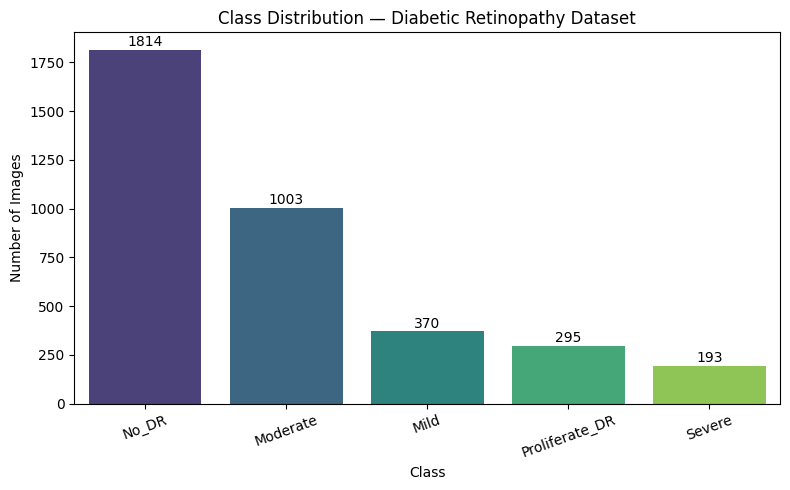

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_counts, x="class", y="image_count", palette="viridis")
plt.title("Class Distribution — Diabetic Retinopathy Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
for i, row in df_counts.iterrows():
    plt.text(i, row["image_count"] + 20, str(row["image_count"]), ha="center")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "class_distribution.png"), dpi=150)
plt.show()

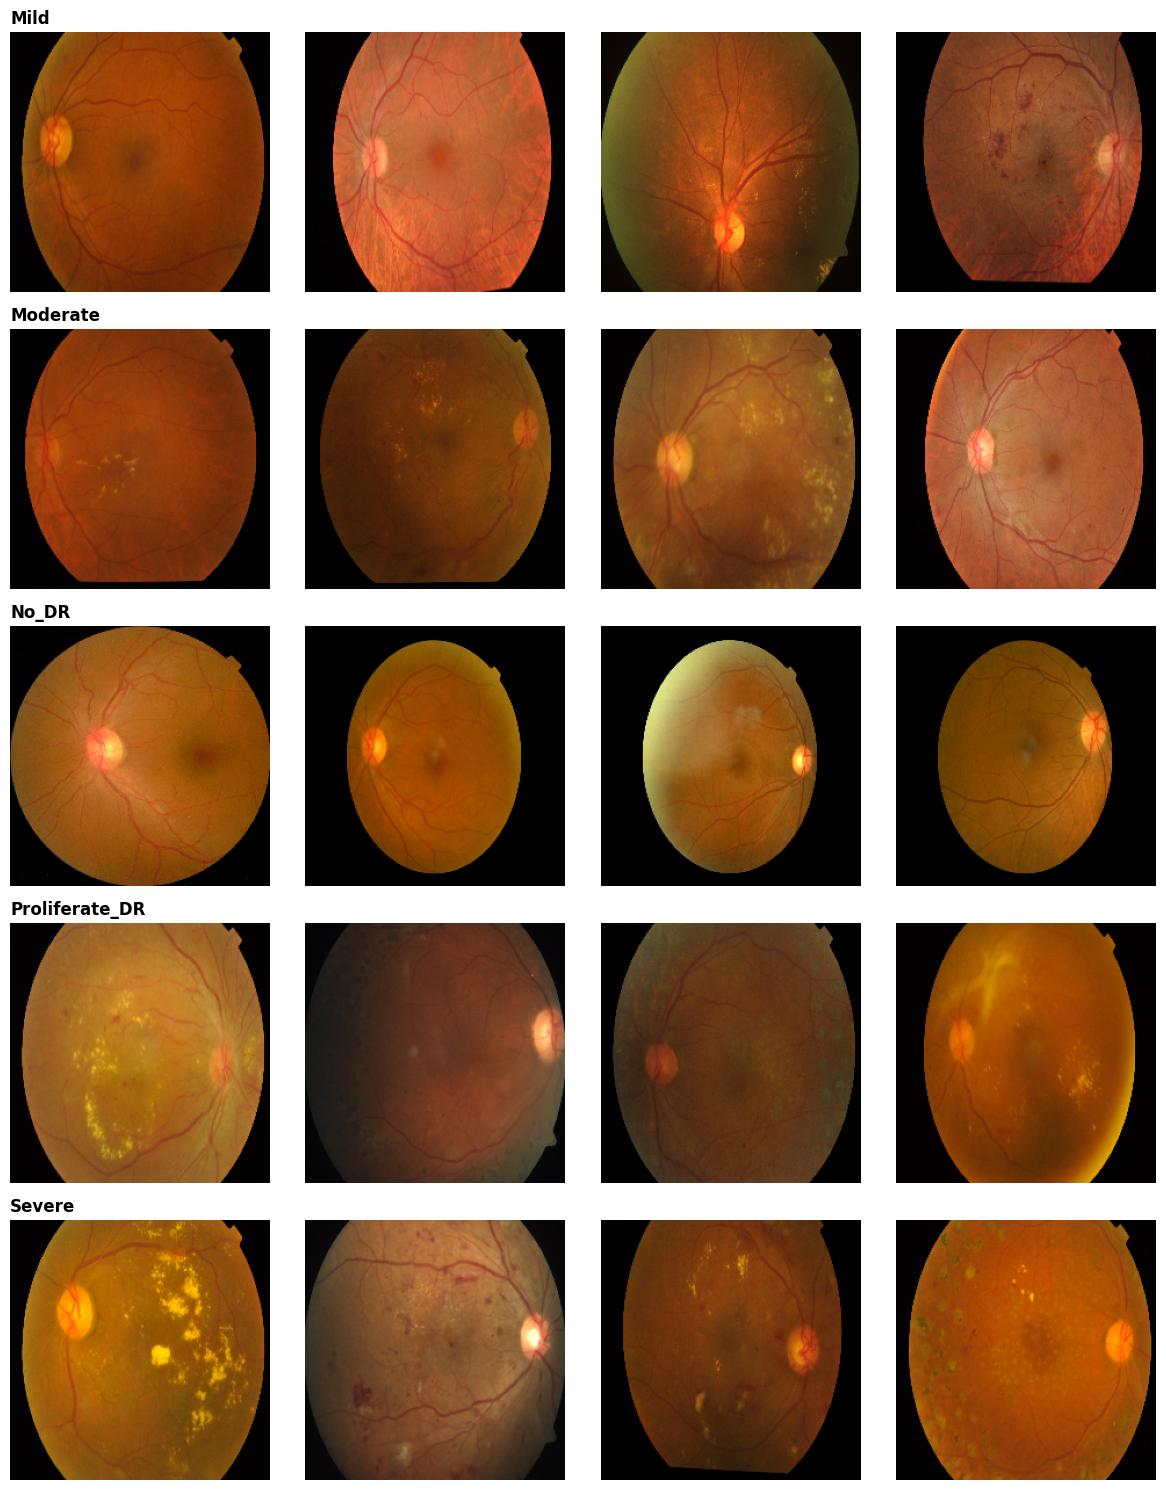

In [21]:
# Visualize a few sample images per class
fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3 * len(classes)))

for row, cls in enumerate(classes):
    cls_dir = os.path.join(DATASET_PATH, cls)
    sample_files = os.listdir(cls_dir)[:4]
    for col, fname in enumerate(sample_files):
        img = tf.keras.utils.load_img(os.path.join(cls_dir, fname), target_size=IMG_SIZE)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12)
    axes[row, 0].set_title(cls, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [22]:
full_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = full_dataset.class_names
print("Classes:", class_names)

# Persist class_names so training and inference (Gradio) always agree — fixes label drift
with open(os.path.join(PROJECT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f)

NUM_CLASSES = len(class_names)

dataset_size = full_dataset.cardinality().numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_dataset = full_dataset.take(train_size)
remaining = full_dataset.skip(train_size)
val_dataset = remaining.take(val_size)
test_dataset = remaining.skip(val_size)

print(f"Train batches: {train_dataset.cardinality().numpy()}")
print(f"Val batches:   {val_dataset.cardinality().numpy()}")
print(f"Test batches:  {test_dataset.cardinality().numpy()}")

Found 3675 files belonging to 5 classes.
Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Train batches: 80
Val batches:   17
Test batches:  18


In [23]:
# Data augmentation — training only
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE
SHUFFLE_BUFFER = train_dataset.cardinality().numpy() * BATCH_SIZE

train_dataset = train_dataset.cache().shuffle(SHUFFLE_BUFFER).prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

In [24]:
INPUT_SHAPE = IMG_SIZE + (3,)
FINE_TUNE_AT = 50  # number of trailing layers to unfreeze

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_model.trainable = True

for layer in base_model.layers[:-FINE_TUNE_AT]:
    layer.trainable = False

inputs = Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)                                   # active only during training
x = tf.keras.applications.inception_v3.preprocess_input(x)
x = base_model(x, training=False)                                # keep BatchNorm in inference mode
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(
    NUM_CLASSES,
    activation='softmax',
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

model = Model(inputs, outputs, name="dr_inceptionv3")

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
model.summary()

Model: "dr_inceptionv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,813,029 (83.21 MB)

 Trainable params: 7,183,557 (27.40 MB)

 Non-trainable params: 14,629,472 (55.81 MB)

In [31]:
# Class weights aligned to class_names order
counts_by_class_name = df_counts.set_index("class")["image_count"]
labels_flat = np.concatenate([
    np.full(counts_by_class_name[c], i) for i, c in enumerate(class_names)
])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=labels_flat
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.9864864864864864), 1: np.float64(0.732801595214357), 2: np.float64(0.4051819184123484), 3: np.float64(2.4915254237288136), 4: np.float64(3.8082901554404147)}


In [32]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(PROJECT_DIR, "best_model.keras"),
        monitor="val_loss", save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7
    ),
]

EPOCHS = 20  # early stopping halts training before this if val_loss stops improving

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 559s 7s/step - accuracy: 0.2937 - loss: 1.5723 - val_accuracy: 0.5717 - val_loss: 1.1038 - learning_rate: 1.0000e-05
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 529s 6s/step - accuracy: 0.5289 - loss: 1.3603 - val_accuracy: 0.5790 - val_loss: 1.0247 - learning_rate: 1.0000e-05
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 565s 6s/step - accuracy: 0.5793 - loss: 1.2552 - val_accuracy: 0.6066 - val_loss: 0.9635 - learning_rate: 1.0000e-05
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 521s 7s/step - accuracy: 0.6031 - loss: 1.1809 - val_accuracy: 0.6360 - val_loss: 0.9082 - learning_rate: 1.0000e-05
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 512s 6s/step - accuracy: 0.6277 - loss: 1.1380 - val_accuracy: 0.6452 - val_loss: 0.8713 - learning_rate: 1.0000e-05
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 569s 6s/step - accuracy: 0.6398 - loss: 1.0888 - val_accuracy: 0.6618 - val_loss: 0.8299 - learning_rate: 1.0000e-05
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 546s 6s/step - accuracy: 0.6594 

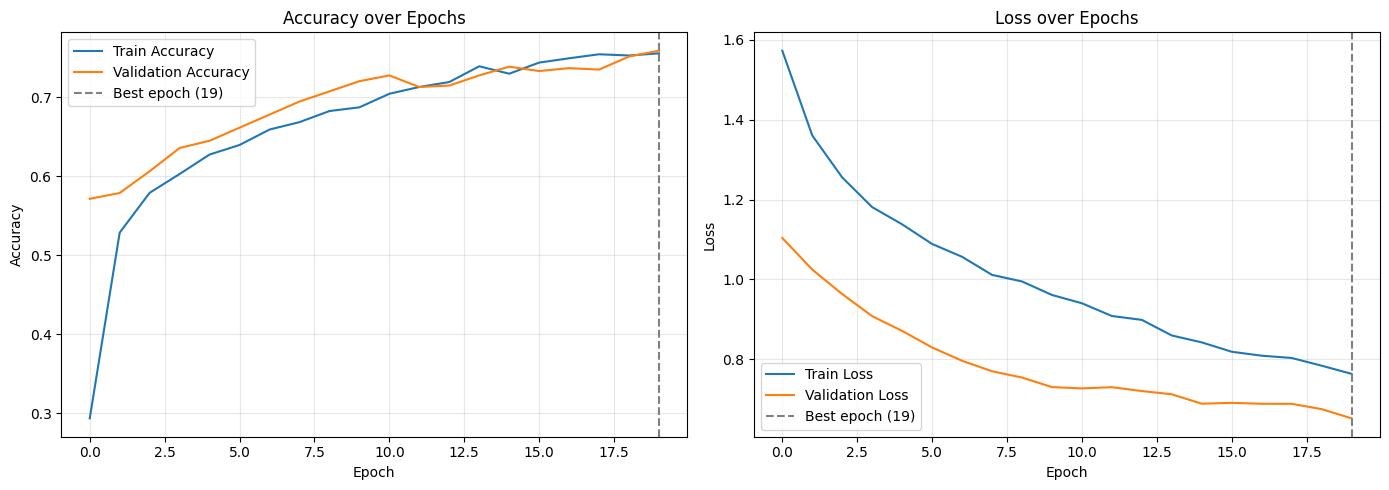

In [33]:
best_epoch = int(np.argmin(history.history['val_loss']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "training_curves.png"), dpi=150)
plt.show()

In [34]:
y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

auc = roc_auc_score(y_true, y_pred_probs, multi_class="ovr", average="macro")
print(f"Macro-average AUC (One-vs-Rest): {auc:.4f}")

                precision    recall  f1-score   support

          Mild      0.339     0.500     0.404        40
      Moderate      0.712     0.477     0.571       155
         No_DR      0.906     0.979     0.941       287
Proliferate_DR      0.488     0.392     0.435        51
        Severe      0.386     0.579     0.463        38

      accuracy                          0.730       571
     macro avg      0.566     0.586     0.563       571
  weighted avg      0.742     0.730     0.726       571

Macro-average AUC (One-vs-Rest): 0.9063


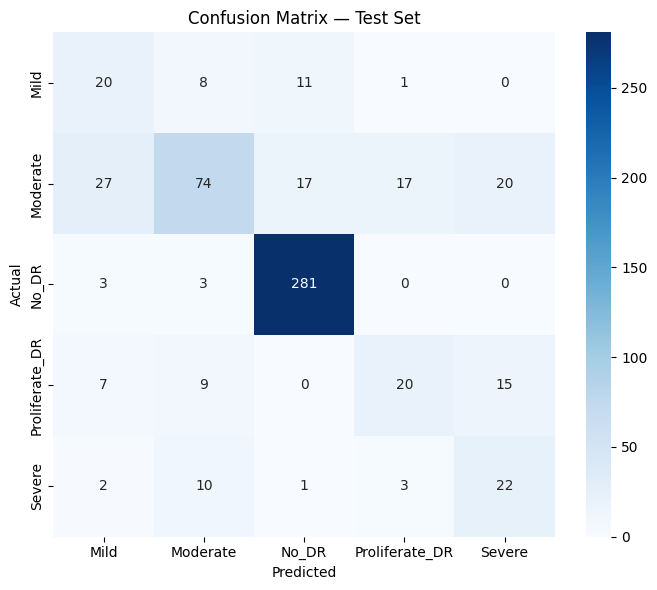

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

Total misclassified: 154 / 571


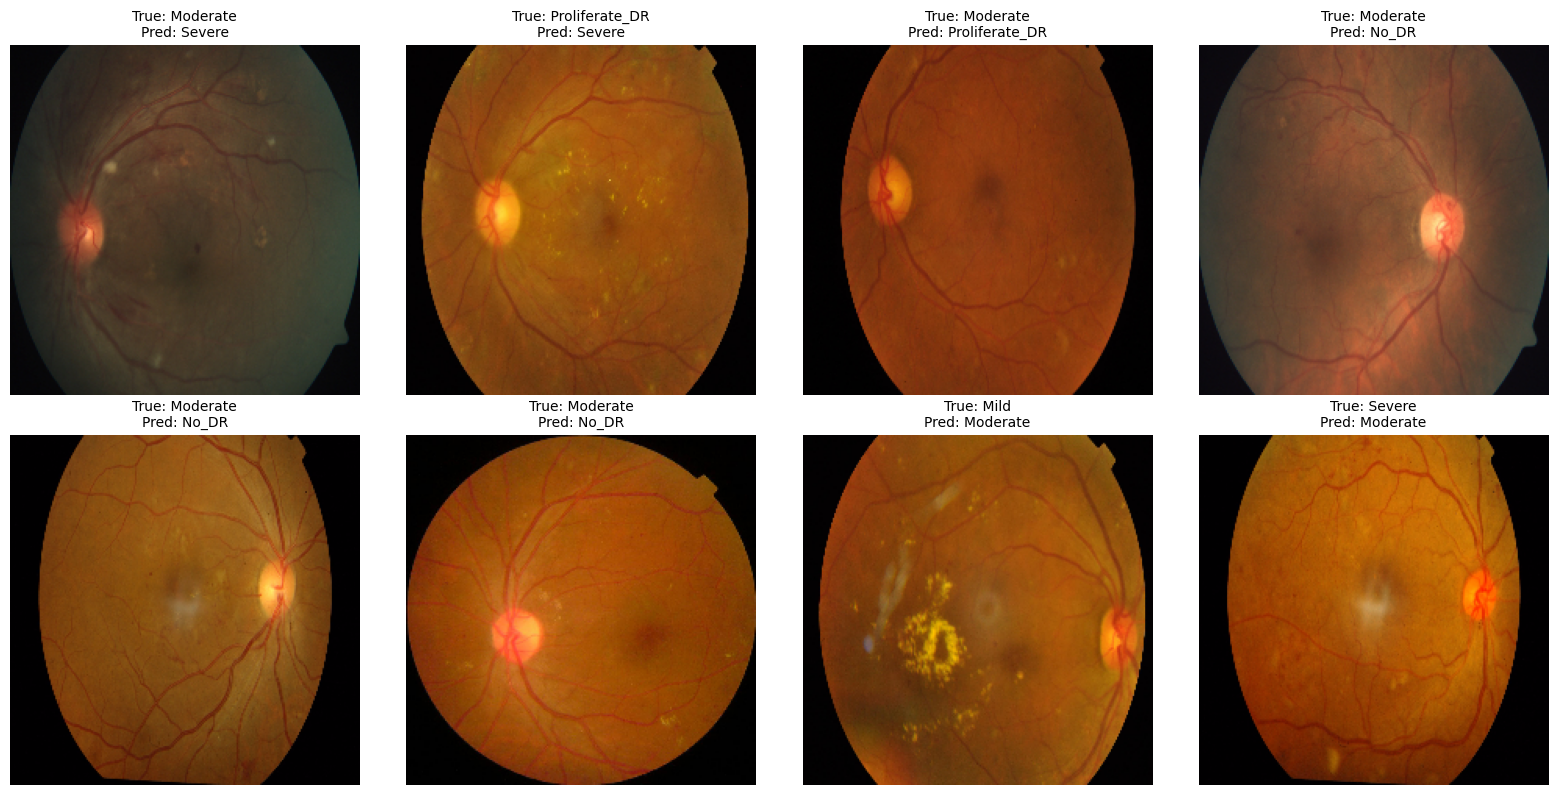

In [36]:
# Inspect a few misclassified examples — useful for error analysis in interviews/README
misclassified_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")

sample_idx = np.random.choice(misclassified_idx, size=min(8, len(misclassified_idx)), replace=False)

all_images = np.concatenate([images.numpy() for images, _ in test_dataset], axis=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(all_images[idx].astype("uint8"))
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [37]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="inception_v3", pred_index=None):
    base = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        model.inputs, [base.output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(image_array, heatmap, alpha=0.4):
    img = image_array.astype("uint8")
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    superimposed = jet_heatmap * alpha + img
    return tf.keras.utils.array_to_img(superimposed)

In [39]:
final_model_path = os.path.join(PROJECT_DIR, "dr_model.keras")
model.save(final_model_path)
assert os.path.exists(final_model_path)
print(f"Model saved to: {final_model_path}")

Model saved to: /content/drive/MyDrive/PROJECT/diabetic-retinopathy-detection/dr_model.keras


In [40]:
!pip install -q gradio

In [41]:
import gradio as gr

MODEL_PATH = os.path.join(PROJECT_DIR, "dr_model.keras")
CLASS_NAMES_PATH = os.path.join(PROJECT_DIR, "class_names.json")

inference_model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r") as f:
    inference_class_names = json.load(f)  # same source of truth as training — no label drift

def predict(input_image):
    img = input_image.resize((224, 224))
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.inception_v3.preprocess_input(img)

    pred = inference_model.predict(img, verbose=0)[0]
    index = int(np.argmax(pred))
    confidence = float(np.max(pred) * 100)

    return (
        {inference_class_names[i]: float(pred[i]) for i in range(len(inference_class_names))},
        f"Prediction: {inference_class_names[index]}\nConfidence: {confidence:.2f}%"
    )

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Retinal Image"),
    outputs=[
        gr.Label(num_top_classes=5, label="Prediction Probabilities"),
        gr.Textbox(label="Result")
    ],
    title="🩺 Diabetic Retinopathy Detection",
    description=(
        "Upload a retinal fundus image to predict the stage of diabetic retinopathy "
        "using a fine-tuned InceptionV3 model. This is a portfolio/educational demo, "
        "not a diagnostic tool."
    )
)

demo.launch(share=True)  # NOTE: public share link expires after ~1 week

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d3cd9848ab78770c2a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
